In [58]:
import pandas as pd
import numpy as np



In [59]:
df = pd.read_csv("titanic.csv")

In [60]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 887 entries, 0 to 886
Data columns (total 8 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Survived                 887 non-null    int64  
 1   Pclass                   887 non-null    int64  
 2   Name                     887 non-null    object 
 3   Sex                      887 non-null    object 
 4   Age                      887 non-null    float64
 5   Siblings/Spouses Aboard  887 non-null    int64  
 6   Parents/Children Aboard  887 non-null    int64  
 7   Fare                     887 non-null    float64
dtypes: float64(2), int64(4), object(2)
memory usage: 55.6+ KB


In [61]:
df.head()

,Survived,Pclass,Name,Sex,Age,Siblings/Spouses Aboard,Parents/Children Aboard,Fare
0,0,3,Mr. Owen Harris Braund,male,22.0,1,0,7.2500
1,1,1,Mrs. John Bradley (Florence Briggs Thayer) Cum...,female,38.0,1,0,71.2833
2,1,3,Miss. Laina Heikkinen,female,26.0,0,0,7.9250
3,1,1,Mrs. Jacques Heath (Lily May Peel) Futrelle,female,35.0,1,0,53.1000
4,0,3,Mr. William Henry Allen,male,35.0,0,0,8.0500


In [62]:
df['Name']

0                                 Mr. Owen Harris Braund
1      Mrs. John Bradley (Florence Briggs Thayer) Cum...
2                                  Miss. Laina Heikkinen
3            Mrs. Jacques Heath (Lily May Peel) Futrelle
4                                Mr. William Henry Allen
                             ...                        
882                                 Rev. Juozas Montvila
883                          Miss. Margaret Edith Graham
884                       Miss. Catherine Helen Johnston
885                                 Mr. Karl Howell Behr
886                                   Mr. Patrick Dooley
Name: Name, Length: 887, dtype: object

In [63]:
df['Name'].str.split(' ', expand = True)[0].value_counts()

0
Mr.          513
Miss.        182
Mrs.         125
Master.       40
Dr.            7
Rev.           6
Col.           2
Mlle.          2
Major.         2
Ms.            1
Mme.           1
Don.           1
Lady.          1
Sir.           1
Capt.          1
the            1
Jonkheer.      1
Name: count, dtype: int64

In [64]:
print("Toplam Eksik Sayisi:\n", df.isna ().sum())
# Sadece eksik veri barindiran sutunlari filtreleme
eksik_oran = (df.isna ().sum() / len(df)) * 100
print("\nEksiklik Orani (%):\n", eksik_oran [ eksik_oran > 0])

Toplam Eksik Sayisi:
 Survived                   0
Pclass                     0
Name                       0
Sex                        0
Age                        0
Siblings/Spouses Aboard    0
Parents/Children Aboard    0
Fare                       0
dtype: int64

Eksiklik Orani (%):
 Series([], dtype: float64)


In [65]:
df['yetiskinler'] = df["Age"] > 30
df['birinci_sinif'] = df["Pclass"] == 1

In [66]:
df.head()

,Survived,Pclass,Name,Sex,Age,Siblings/Spouses Aboard,Parents/Children Aboard,Fare,yetiskinler,birinci_sinif
0,0,3,Mr. Owen Harris Braund,male,22.0,1,0,7.2500,False,False
1,1,1,Mrs. John Bradley (Florence Briggs Thayer) Cum...,female,38.0,1,0,71.2833,True,True
2,1,3,Miss. Laina Heikkinen,female,26.0,0,0,7.9250,False,False
3,1,1,Mrs. Jacques Heath (Lily May Peel) Futrelle,female,35.0,1,0,53.1000,True,True
4,0,3,Mr. William Henry Allen,male,35.0,0,0,8.0500,True,False


In [67]:
df['Survived'].value_counts(normalize=True)

Survived
0    0.614431
1    0.385569
Name: proportion, dtype: float64

### Uygulama 1) 

In [68]:
df1 = pd.read_csv('satislar.csv')

In [69]:
df1.head()

,siparis_id,tarih,kategori,urun,adet,fiyat,sehir
0,SIP0001,2026-03-28,Ev,Süpürge,5.0,3822.0,İzmir
1,SIP0002,2026-02-22,Ev,Süpürge,5.0,3221.0,Ankara
2,SIP0003,2026-03-30,Giyim,Pantolon,2.0,1234.0,İstanbul
3,SIP0004,2026-03-03,Ev,Ütü,2.0,2097.0,Ankara
4,SIP0005,2026-01-03,Ev,Airfryer,3.0,1949.0,İstanbul


In [70]:
df1.describe()

,adet,fiyat
count,183.000000,180.000000
mean,2.885246,2565.411111
std,1.483592,1454.396877
min,1.000000,52.000000
25%,1.000000,1330.500000
50%,3.000000,2629.000000
75%,4.000000,3874.750000
max,5.000000,4979.000000


In [71]:
df1.isna().sum()

siparis_id     0
tarih          0
kategori       0
urun           0
adet          17
fiyat         20
sehir          0
dtype: int64

In [72]:
df1['fiyat'] = df1['fiyat'].fillna(df1['fiyat'].median())
df1['adet'] = df1['adet'].fillna(df1['adet'].median())

In [73]:
df1.isna().sum()

siparis_id    0
tarih         0
kategori      0
urun          0
adet          0
fiyat         0
sehir         0
dtype: int64

In [74]:
df1['toplam']= df1['adet'] * df1['fiyat']

In [75]:
df1.head()

,siparis_id,tarih,kategori,urun,adet,fiyat,sehir,toplam
0,SIP0001,2026-03-28,Ev,Süpürge,5.0,3822.0,İzmir,19110.0
1,SIP0002,2026-02-22,Ev,Süpürge,5.0,3221.0,Ankara,16105.0
2,SIP0003,2026-03-30,Giyim,Pantolon,2.0,1234.0,İstanbul,2468.0
3,SIP0004,2026-03-03,Ev,Ütü,2.0,2097.0,Ankara,4194.0
4,SIP0005,2026-01-03,Ev,Airfryer,3.0,1949.0,İstanbul,5847.0


In [84]:
df1.groupby('kategori')["toplam"].sum()


kategori
Elektronik    530216.0
Ev            525931.0
Giyim         437394.0
Name: toplam, dtype: float64

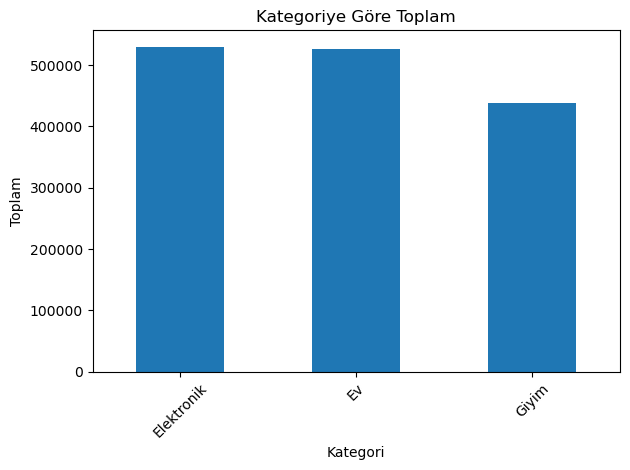

In [85]:
import matplotlib.pyplot as plt

df1.groupby('kategori')['toplam'].sum().plot(kind='bar')

plt.xlabel('Kategori')
plt.ylabel('Toplam')
plt.title('Kategoriye Göre Toplam')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [87]:
df1['tarih'] = pd.to_datetime(df1['tarih'])

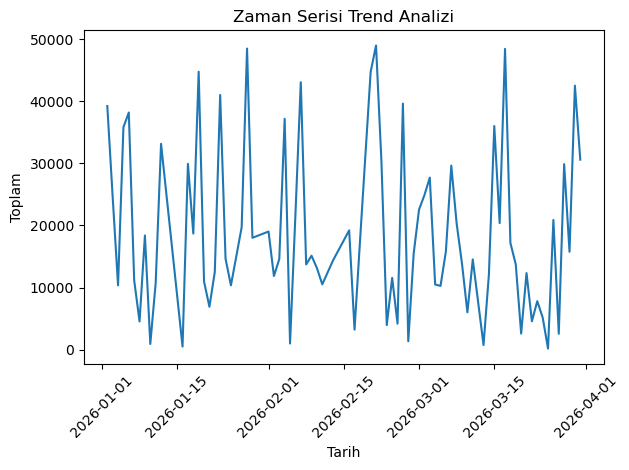

In [91]:
trend = df1.groupby('tarih')['toplam'].sum().sort_index()
plt.figure()
plt.plot(trend.index, trend.values)

plt.xlabel("Tarih")
plt.ylabel("Toplam")
plt.title("Zaman Serisi Trend Analizi")

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

### Uygulama 2)

In [92]:
import pandas as pd 
import matplotlib.pyplot as plt

In [93]:
df2 = pd.read_csv("ogrenci_notlari.csv")

In [94]:
df2.head()

,ogrenci_id,bolum,ders,vize,final,devamsizlik
0,OGR0001,Bilgisayar,Programlama,59.7,72.3,14
1,OGR0002,Elektrik,Programlama,52.7,NaN,7
2,OGR0003,Endüstri,İstatistik,NaN,NaN,5
3,OGR0004,Elektrik,Programlama,48.9,45.1,14
4,OGR0005,Endüstri,Programlama,69.0,71.6,2


In [95]:
df2.isna().sum()

ogrenci_id      0
bolum           0
ders            0
vize           29
final          28
devamsizlik     0
dtype: int64

In [97]:
df2["vize"] = df2["vize"].fillna(df2["vize"].mean())
df2["final"] = df2["final"].fillna(df2["final"].mean())

In [98]:
df2.isna().sum()

ogrenci_id     0
bolum          0
ders           0
vize           0
final          0
devamsizlik    0
dtype: int64

In [99]:
df2["basari_notu"] =( df2["vize"] *4/10) +  ( df2["final"] *6/10)
df2.head()

,ogrenci_id,bolum,ders,vize,final,devamsizlik,basari_notu
0,OGR0001,Bilgisayar,Programlama,59.700000,72.300000,14,67.260000
1,OGR0002,Elektrik,Programlama,52.700000,65.164706,7,60.178824
2,OGR0003,Endüstri,İstatistik,60.204797,65.164706,5,63.180742
3,OGR0004,Elektrik,Programlama,48.900000,45.100000,14,46.620000
4,OGR0005,Endüstri,Programlama,69.000000,71.600000,2,70.560000


In [102]:
df2["durum"] = (df2["basari_notu"] >= 50).astype(int)

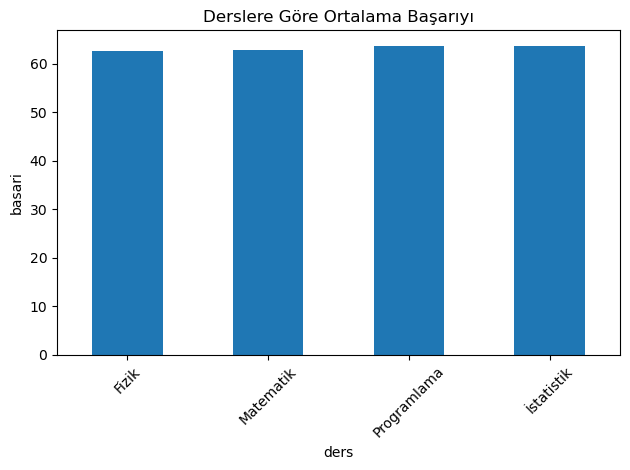

In [106]:
import matplotlib.pyplot as plt

df2.groupby('ders')['basari_notu'].mean().plot(kind='bar')

plt.xlabel('ders')
plt.ylabel('basari')
plt.title('Derslere Göre Ortalama Başarıyı')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

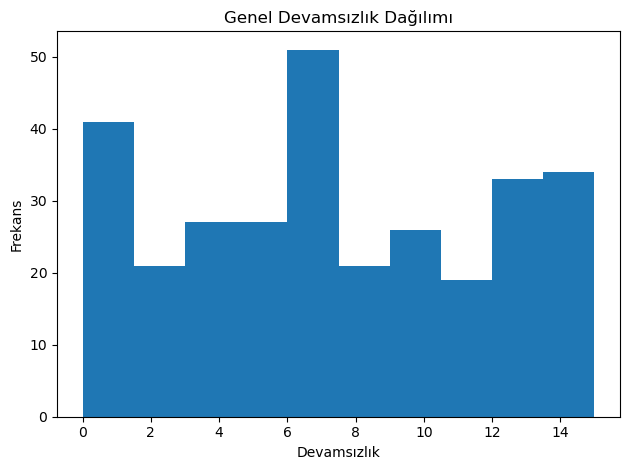

In [111]:
plt.figure()
plt.hist(df2['devamsizlik'], bins=10)

plt.xlabel("Devamsızlık")
plt.ylabel("Frekans")
plt.title("Genel Devamsızlık Dağılımı")

plt.tight_layout()
plt.show()

In [112]:
df2['devamsizlik'].corr(df2['basari_notu'])

np.float64(-0.5522107116649816)

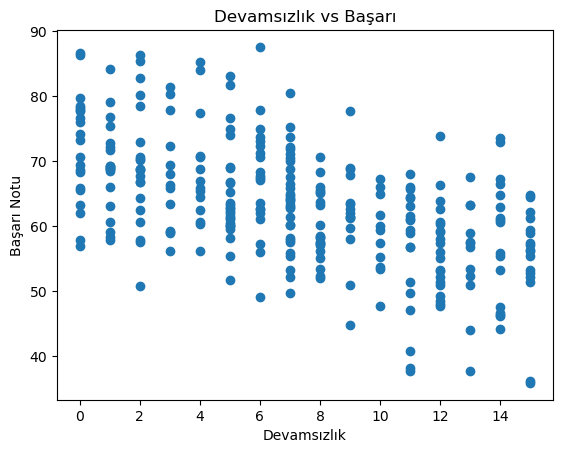

In [113]:
import matplotlib.pyplot as plt

plt.figure()
plt.scatter(df2['devamsizlik'], df2['basari_notu'])

plt.xlabel("Devamsızlık")
plt.ylabel("Başarı Notu")
plt.title("Devamsızlık vs Başarı")

plt.show()

In [114]:
df2.groupby('ders')['basari_notu'].mean().sort_values()

ders
Fizik          62.660851
Matematik      62.791448
İstatistik     63.582854
Programlama    63.662392
Name: basari_notu, dtype: float64

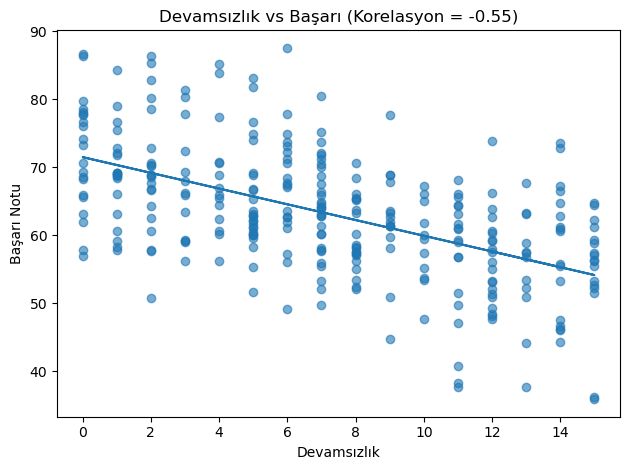

In [115]:
import matplotlib.pyplot as plt
import numpy as np

plt.figure()

# Scatter (biraz şeffaflık ekledik)
plt.scatter(df2['devamsizlik'], 
            df2['basari_notu'], 
            alpha=0.6)

# Trend (regresyon) çizgisi
z = np.polyfit(df2['devamsizlik'], df2['basari_notu'], 1)
p = np.poly1d(z)

plt.plot(df2['devamsizlik'], 
         p(df2['devamsizlik']))

# Korelasyon değeri
corr = df2['devamsizlik'].corr(df2['basari_notu'])

plt.title(f"Devamsızlık vs Başarı (Korelasyon = {corr:.2f})")
plt.xlabel("Devamsızlık")
plt.ylabel("Başarı Notu")

plt.tight_layout()
plt.show()